## Uppal 2025 dual-layer equivalent sources method
In this notebook, we use the method by [Upal, 2025](https://github.com/compgeolab/eqs-gb-norm-of-b) to fit both lower and higher wavelengths.

In [2]:
import pygmt
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import bordado as bd
import boule as bl
import harmonica as hm
import verde as vd
import itertools
from scipy.interpolate import griddata

import spherical as sph

Import the real data to create our synthetic.

In [3]:
caminho = "../data/parana-basin-magnetic-processed.csv"

df = pd.read_csv(caminho, sep=',', comment="#")
df.columns = ['FID','ESTACAO','LINHA','X','Y','LATITUDE','LONGITUDE','DATA','HORA','GPSALT','BARO','MAGBRU','MAGCOM','MAGBASE','MAGCOR','MAGNIV','MAGMIC','MAGIGRF','IGRF','MDT']

lat = df['LATITUDE']
lon = df['LONGITUDE']
height = df["GPSALT"].values

Reduce the data so we can run faster.

In [37]:
reducer = vd.BlockReduce(reduction=np.median, spacing= 0.1)

coordinates, height_new = reducer.filter(
    (df.LONGITUDE, df.LATITUDE), df.GPSALT
)
lon, lat = coordinates

coordinates = (lon, lat, height_new)
coordinates_real = (df['LONGITUDE'], df['LATITUDE'], df["GPSALT"].values)

print(coordinates[0].size)
print(coordinates_real[0].size)

6875
2256991


/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.13/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7f28044eeb60> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.13/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7f28044eeb60> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


Ignore the real data anda create our synthetic sources and regional.

In [38]:
inclination, declination = -25, -20  

#Source 1 
source1a, _ = bd.profile_coordinates((-57,-14),(-54,-15.5),size= 1000, non_dimensional_coords= - 30e3)
magnetic_moment1a = hm.magnetic_angles_to_vec(np.full(1000, 7e10), np.full(1000, inclination),np.full(1000, declination))

source1b, _ = bd.profile_coordinates((-57,-16),(-48,-13),size= 1000,non_dimensional_coords=  - 30e3)
magnetic_moment1b = hm.magnetic_angles_to_vec(np.full(1000, 7e10), np.full(1000, inclination),np.full(1000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source1a, source1b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment1a, magnetic_moment1b)]

#Source 2 
source2a, _= bd.profile_coordinates((-52,-16),(-53,-16),size= 300,non_dimensional_coords=  - 25e3)
magnetic_moment2a = hm.magnetic_angles_to_vec(np.full(300, 6e10), np.full(300, inclination),np.full(300, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source2a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment2a)]

source2b, _= bd.profile_coordinates((-54,-16.7),(-53,-16.7), size= 300,non_dimensional_coords= - 22e3)
magnetic_moment2b = hm.magnetic_angles_to_vec(np.full(300, 6e10), np.full(300, inclination),np.full(300, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source2b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment2b)]

#Source 3
source3, _= bd.profile_coordinates((-54,-17.5),(-54.5,-17.5),size= 150,non_dimensional_coords=  - 20e3)
magnetic_moment3 = hm.magnetic_angles_to_vec(np.full(150, 6e10), np.full(150, inclination),np.full(150, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source3)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment3)]

#Source 4
source4a, _= bd.profile_coordinates((-54,-20),(-53.5,-19),size= 250, non_dimensional_coords= - 17e3)
magnetic_moment4a = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source4a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment4a)]

source4b, _= bd.profile_coordinates((-54.5,-19.5),(-54,-18.5),size= 250,non_dimensional_coords=  - 16e3)
magnetic_moment4b = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source4b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment4b)]

source4c, _= bd.profile_coordinates((-54.6,-20.3),(-54.6,-20.4),size= 100,non_dimensional_coords=  - 13e3)
magnetic_moment4c = hm.magnetic_angles_to_vec(np.full(100, 6e10), np.full(100, inclination),np.full(100, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source4c)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment4c)]

#Source 5
source5a, _= bd.profile_coordinates((-52,-19),(-49,-19),size= 250,non_dimensional_coords=  - 15e3)
magnetic_moment5a = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5a)]

source5b, _= bd.profile_coordinates((-50,-19.6),(-48,-19.6),size= 250,non_dimensional_coords=  - 14e3)
magnetic_moment5b = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5b)]

source5c, _= bd.profile_coordinates((-48,-20),(-45,-20),size= 250,non_dimensional_coords= - 15e3)
magnetic_moment5c = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5c)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5c)]

source5d, _= bd.profile_coordinates((-45,-20.4),(-48,-20.4),size= 250,non_dimensional_coords=  - 13e3)
magnetic_moment5d = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5d)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5d)]

source5e, _= bd.profile_coordinates((-45,-20.9),(-48,-20.9),size= 250,non_dimensional_coords=  - 12e3)
magnetic_moment5e = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5e)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5e)]

source5f, _= bd.profile_coordinates((-45,-13),(-52,-18.9),size= 500,non_dimensional_coords=  - 11e3)
magnetic_moment5f = hm.magnetic_angles_to_vec(np.full(500, 6e10), np.full(500, inclination),np.full(500, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5f)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5f)]

source5g= vd.scatter_points(region= (-52.3,-52.3,-19.6,-19.6), size= 1, extra_coords=   - 12e3)
magnetic_moment5g = hm.magnetic_angles_to_vec(np.full(1,8e11), np.full(1,45), np.full(1,0))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5g)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5g)]

#Source 6
source6a, _= bd.profile_coordinates((-48,-20.9),(-51,-23.9),size= 250,non_dimensional_coords=  - 15e3)
magnetic_moment6a = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source6a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment6a)]

source6b, _= bd.profile_coordinates((-47,-20.9),(-50,-24.9),size= 250,non_dimensional_coords=  - 14e3)
magnetic_moment6b = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source6b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment6b)]

source6c, _= bd.profile_coordinates((-51.4,-22),(-50.2,-21),size=250,non_dimensional_coords= - 13e3)
magnetic_moment6c = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source6c)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment6c)]

#Source 7
source7a, _= bd.profile_coordinates((-52,-16),(-53.8,-21),size= 250,non_dimensional_coords= - 12e3)
magnetic_moment7a = hm.magnetic_angles_to_vec(np.full(250, -6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source7a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment7a)]

#Source 8 
source8a, _= bd.profile_coordinates((-57,-26.5),(-54,-23.1),size= 400,non_dimensional_coords=  - 15e3)
magnetic_moment8a = hm.magnetic_angles_to_vec(np.full(400, -9e10), np.full(400, inclination),np.full(400, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source8a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment8a)]


#Source 9
source9a, _= bd.profile_coordinates((-48,-26.5),(-54,-22),size= 5000,non_dimensional_coords=  - 6e3)
magnetic_moment9a = hm.magnetic_angles_to_vec(np.full(5000, -6e8), np.full(5000, inclination),np.full(5000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source9a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment9a)]

source9b, _= bd.profile_coordinates((-46.5,-26.4),(-51.5,-22.2),size= 5000, non_dimensional_coords= - 3e3)
magnetic_moment9b = hm.magnetic_angles_to_vec(np.full(5000, -6e8), np.full(5000, inclination),np.full(5000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source9b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment9b)]

source9c, _= bd.profile_coordinates((-48,-26.6),(-51,-22.5),size= 5000,non_dimensional_coords=  - 5e3)
magnetic_moment9c = hm.magnetic_angles_to_vec(np.full(5000, -6e8), np.full(5000, inclination),np.full(5000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source9c)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment9c)]

source9d, _= bd.profile_coordinates((-51.4,-19),(-45,-26.5),size= 5000,non_dimensional_coords=  - 4e3)
magnetic_moment9d = hm.magnetic_angles_to_vec(np.full(5000, -6e8), np.full(5000, inclination),np.full(5000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source9d)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment9d)]

#Regional Field
regional= vd.scatter_points(region=(-55,-50,-23,-17), size=90, extra_coords=-60e3, random_state=1)
magnetic_moment_reg = hm.magnetic_angles_to_vec(np.full(90, -9e12), np.full(90, -90),np.full(90, 45))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, regional)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment_reg)]

In [39]:
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source_coordinates, magnetic_moment)
magnetic_anomaly = hm.total_field_anomaly(magnetic_field, inclination, declination)


#Random noise

noise_level =  0.01 * vd.maxabs(magnetic_anomaly)

magnetic_anomaly += np.random.default_rng(42).normal(
    0, noise_level, size=magnetic_anomaly.shape
)

(np.float64(-57.040440415000006),
 np.float64(-46.376795885),
 np.float64(-24.8825455265),
 np.float64(-13.5526593435))

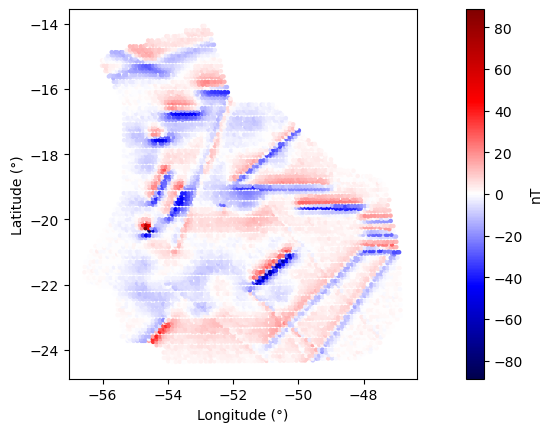

In [40]:
scale = vd.maxabs(magnetic_anomaly)
plt.scatter(coordinates[0], coordinates[1],  c = magnetic_anomaly, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

Use our function to create a grid of true total field anomaly.

In [41]:
grid_coord = vd.grid_coordinates((-56.5, -47, -25, -14), shape=(150, 150), extra_coords= 500)

magnetic_field_grid = sph.dipole_magnetic_geodetic(grid_coord, source_coordinates, magnetic_moment)
grided_dd_anomaly = hm.total_field_anomaly(magnetic_field_grid, inclination, declination)

# Deep equivalent sources
Use a block reduce method to create our deep equivalent sources.

In [42]:
reducer = vd.BlockReduce(reduction=np.mean, spacing=0.3,  center_coordinates=False, drop_coords=False)
blocked_deep_equivalent_sources, magnetic_anomaly_reduced = reducer.filter(coordinates, magnetic_anomaly)

print(blocked_deep_equivalent_sources[0].size)

782


/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.13/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function mean at 0x7f2818246fc0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.13/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function mean at 0x7f2818246fc0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


Plot the data so we can visualize the reduced version.

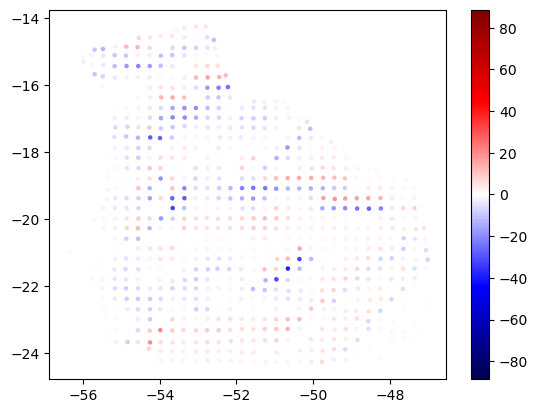

In [43]:
plt.scatter(*blocked_deep_equivalent_sources[:2], c = magnetic_anomaly_reduced,s = 5, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar()

In [44]:
def estimate_depth(coordinates):
        """
        Estimate a reasonable depth if one isn't given.
        """
        ellipsoid=bl.WGS84

        coslat = np.cos(np.radians(coordinates[1]))
        sinlat = np.sin(np.radians(coordinates[1]))
        N = ellipsoid.prime_vertical_radius(sinlat)
        b = ellipsoid.semiminor_axis
        a = ellipsoid.semimajor_axis
        coordinates_cartesian = (
            (N + coordinates[2]) * coslat * np.cos(np.radians(coordinates[0])),
            (N + coordinates[2]) * coslat * np.sin(np.radians(coordinates[0])),
            (b**2 * N / a**2 + coordinates[2]) * sinlat,
        )
        return bd.neighbor_distance_statistics(coordinates_cartesian, "median", k=10)

Do the croos validation to fit the best equivalent souce

In [45]:
damping_deep = [1e-1, 1e1, 1e2, 1e3,1e4,1e5, 1e6]
depths = np.mean(estimate_depth(blocked_deep_equivalent_sources))
source_depth_deep = [depths, depths*1.25,depths*2.5, depths*4.25]
parameter_sets_deep = [
    dict(damping=combo[0], depth=combo[1])
    for combo in itertools.product(damping_deep, source_depth_deep)
]
print("Number of combinations:", len(parameter_sets_deep))


Number of combinations: 28


In [46]:
%%time
kfold = vd.BlockKFold(
    spacing=0.5,
    shuffle=True,
    random_state=0,
    balance=True,
)
features = np.transpose(blocked_deep_equivalent_sources[:2])
scores_deep = []
damping_deep = []
source_depth_deep = []
for parameters in parameter_sets_deep:    
    print(parameters)
    eqs_deep = sph.EquivalentSourcesMagGeod(**parameters)
    tmp = []
    for train, test in kfold.split(features):
        eqs_deep.fit(
            [c[train] for c in blocked_deep_equivalent_sources],
            inclination, 
            declination,
            magnetic_anomaly_reduced[train] 
        )
        predicted = hm.total_field_anomaly(
            eqs_deep.predict([c[test] for c in blocked_deep_equivalent_sources]),
            inclination, declination
        )
        tmp.append(np.linalg.norm(magnetic_anomaly_reduced[test] - predicted))
    scores_deep.append(np.mean(tmp))
    damping_deep.append(parameters['damping'])
    source_depth_deep.append(parameters['depth'])
best = np.argmin(scores_deep)
parameter_sets_deep[best]

{'damping': 0.1, 'depth': np.float64(45566.95671260932)}
{'damping': 0.1, 'depth': np.float64(56958.69589076165)}
{'damping': 0.1, 'depth': np.float64(113917.3917815233)}
{'damping': 0.1, 'depth': np.float64(193659.5660285896)}
{'damping': 10.0, 'depth': np.float64(45566.95671260932)}
{'damping': 10.0, 'depth': np.float64(56958.69589076165)}
{'damping': 10.0, 'depth': np.float64(113917.3917815233)}
{'damping': 10.0, 'depth': np.float64(193659.5660285896)}
{'damping': 100.0, 'depth': np.float64(45566.95671260932)}
{'damping': 100.0, 'depth': np.float64(56958.69589076165)}
{'damping': 100.0, 'depth': np.float64(113917.3917815233)}
{'damping': 100.0, 'depth': np.float64(193659.5660285896)}
{'damping': 1000.0, 'depth': np.float64(45566.95671260932)}
{'damping': 1000.0, 'depth': np.float64(56958.69589076165)}
{'damping': 1000.0, 'depth': np.float64(113917.3917815233)}
{'damping': 1000.0, 'depth': np.float64(193659.5660285896)}
{'damping': 10000.0, 'depth': np.float64(45566.95671260932)}
{'d

{'damping': 1000.0, 'depth': np.float64(113917.3917815233)}

Best parameters: {'damping': 1000.0, 'depth': np.float64(113917.3917815233)}
Best RMSE: 79.816 nT


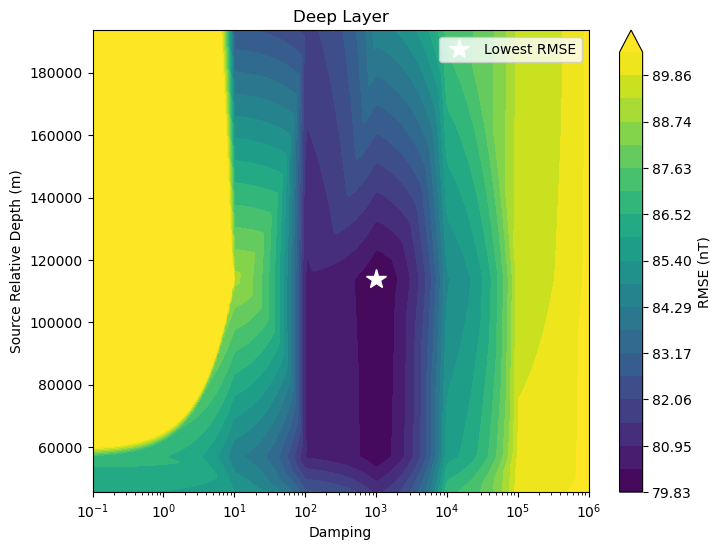

In [47]:
damping_values_deep = np.array(damping_deep)
depth_values_deep = np.array(source_depth_deep)
score_values_deep = np.array(scores_deep)

best_deep = np.argmin(score_values_deep)
best_damping_deep = damping_values_deep[best_deep]
best_depth_deep = depth_values_deep[best_deep]
best_rmse_deep = score_values_deep[best_deep]
best_params_deep = parameter_sets_deep[best_deep]
print("Best parameters:", best_params_deep)
print(f"Best RMSE: {best_rmse_deep:.3f} nT")

x_deep = np.logspace(np.log10(damping_values_deep.min()), np.log10(damping_values_deep.max()), 200)
y_deep = np.linspace(depth_values_deep.min(), depth_values_deep.max(), 200)
X_deep, Y_deep = np.meshgrid(x_deep, y_deep)
Z_deep = griddata(
    (damping_values_deep, depth_values_deep),
    score_values_deep,
    (X_deep, Y_deep),
    method='linear',
)

plt.figure(figsize=(8, 6))
levels_deep = np.linspace(
    Z_deep.min(),
    np.nanpercentile(score_values_deep, 80),
    20,
)
c = plt.contourf(
    X_deep,
    Y_deep,
    Z_deep,
    levels=levels_deep,
    cmap="viridis",
    extend='max',
)
plt.plot(
    best_damping_deep,
    best_depth_deep,
    '*',
    color='white',
    markersize=15,
    label='Lowest RMSE'
)
plt.xscale('log')
plt.xlabel('Damping')
plt.ylabel('Source Relative Depth (m)')
plt.colorbar(c, label='RMSE (nT)')
plt.legend()
plt.title("Deep Layer")
plt.show()

Run the inversion of the deep equivalent sources with the values obtained with the cross-validation.

In [48]:
%%time
eqs_deep = sph.EquivalentSourcesMagGeod(**parameter_sets_deep[best])
eqs_deep.fit(blocked_deep_equivalent_sources, inclination, declination, magnetic_anomaly_reduced)


CPU times: user 408 ms, sys: 0 ns, total: 408 ms
Wall time: 77.7 ms


Predict the deep equivalent sources and calculate the residuals.

In [49]:
predicted_deep =  hm.total_field_anomaly(eqs_deep.predict(coordinates), inclination, declination)
residuals_deep = magnetic_anomaly - predicted_deep 
predicted_b_deep = eqs_deep.predict(coordinates)

residuals_be_deep = magnetic_field[0].ravel() - predicted_b_deep[0]
residuals_bn_deep = magnetic_field[1].ravel() - predicted_b_deep[1]
residuals_bu_deep = magnetic_field[2].ravel() - predicted_b_deep[2]

Plot the predidted and the residuals of the deep layer, to check if the EQS is good.

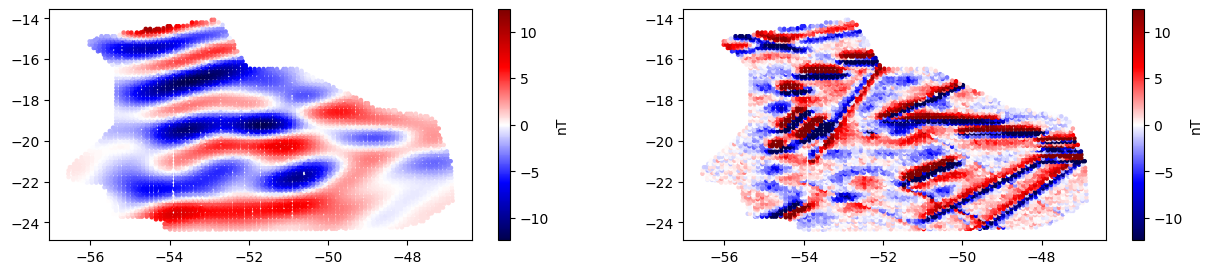

In [50]:
scale_deep = vd.maxabs(predicted_deep)
plt.figure(figsize=(15,3))


plt.subplot(1,2,1)
plt.scatter(coordinates[0], coordinates[1],c = predicted_deep, s = 5,cmap="seismic", vmin=-scale_deep, vmax=scale_deep)
plt.colorbar(label='nT')

plt.subplot(1,2,2)
plt.scatter(coordinates[0], coordinates[1],c = residuals_deep, s = 5,cmap="seismic", vmin=-scale_deep, vmax=scale_deep)
plt.colorbar(label='nT')

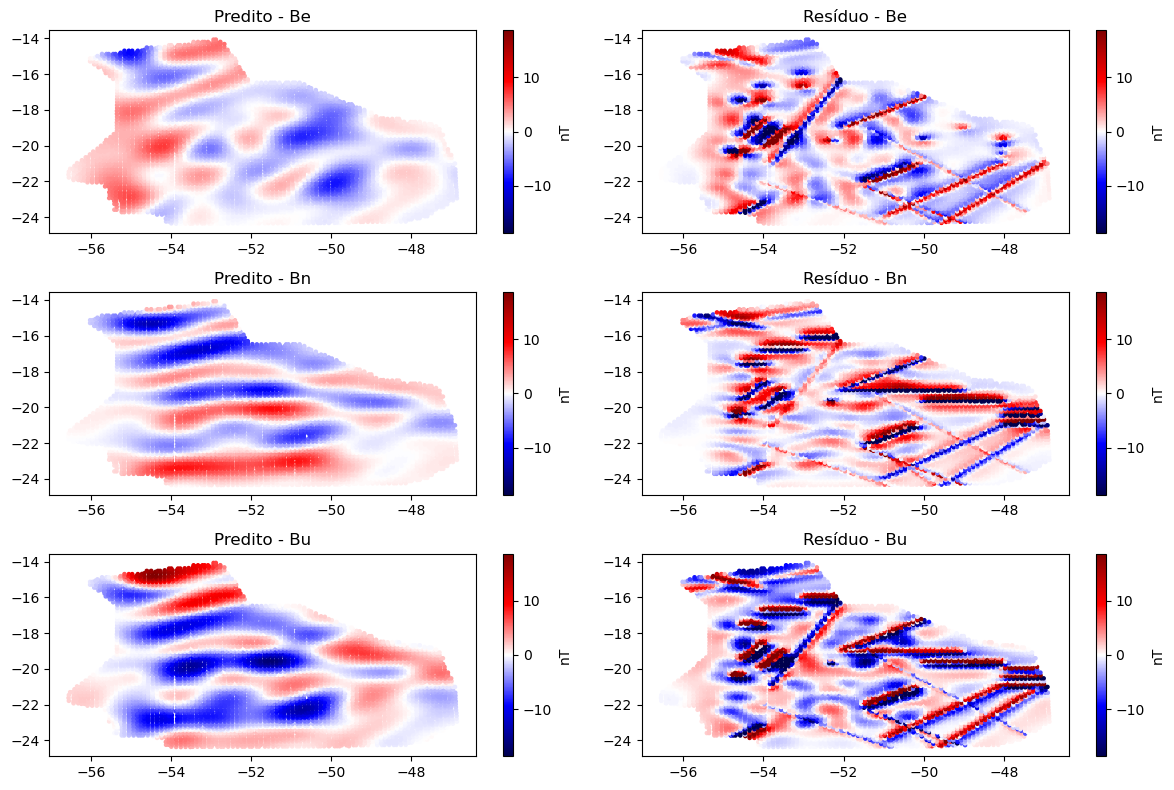

In [51]:
scale_b_deep = vd.maxabs(predicted_b_deep)
plt.figure(figsize=(12, 8))

plt.subplot(3, 2, 1)
plt.scatter(coordinates[0], coordinates[1], c=predicted_b_deep[0], s=5,
            cmap="seismic", vmin=-scale_b_deep, vmax=scale_b_deep)
plt.colorbar(label='nT')
plt.title("Predito - Be")

plt.subplot(3, 2, 2)
plt.scatter(coordinates[0], coordinates[1], c=residuals_be_deep, s=5,
            cmap="seismic", vmin=-scale_b_deep, vmax=scale_b_deep)
plt.colorbar(label='nT')
plt.title("Resíduo - Be")

plt.subplot(3, 2, 3)
plt.scatter(coordinates[0], coordinates[1], c=predicted_b_deep[1], s=5,
            cmap="seismic", vmin=-scale_b_deep, vmax=scale_b_deep)
plt.colorbar(label='nT')
plt.title("Predito - Bn")

plt.subplot(3, 2, 4)
plt.scatter(coordinates[0], coordinates[1], c=residuals_bn_deep, s=5,
            cmap="seismic", vmin=-scale_b_deep, vmax=scale_b_deep)
plt.colorbar(label='nT')
plt.title("Resíduo - Bn")

plt.subplot(3, 2, 5)
plt.scatter(coordinates[0], coordinates[1], c=predicted_b_deep[2], s=5,
            cmap="seismic", vmin=-scale_b_deep, vmax=scale_b_deep)
plt.colorbar(label='nT')
plt.title("Predito - Bu")

plt.subplot(3, 2, 6)
plt.scatter(coordinates[0], coordinates[1], c=residuals_bu_deep, s=5,
            cmap="seismic", vmin=-scale_b_deep, vmax=scale_b_deep)
plt.colorbar(label='nT')
plt.title("Resíduo - Bu")

plt.tight_layout()
plt.show()

# Shallow equivalent sources
Use the gradient-boosted method to generate our shallow equivalent sources.

In [52]:
dampings_shallow = [1e-5,1e-2,1e0,1e2, 1e5]
depths_shallow = [23e3,25e3, 27e3, 29e3, 31e3]
parameter_sets_shallow = [
    dict(damping=combo[0], depth=combo[1])
    for combo in itertools.product(dampings_shallow, depths_shallow)
] 
print("Number of combinations:", len(parameter_sets_shallow))


Number of combinations: 25


In [53]:
%%time
kfold = vd.BlockKFold(
    spacing=1,
    shuffle=True,
    random_state=0,
    balance=True,
)
features = np.transpose(coordinates[:2])
scores_shallow = []
damping_shallow = []
source_depth_shallow = []
for parameters in parameter_sets_shallow:    
    print(parameters)
    eqs_shallow = sph.EquivalentSourcesMagGeodGB(verbose=False,window_size=200e3,**parameters)
    tmp = []
    for train, test in kfold.split(features):
        eqs_shallow.fit(
            [c[train] for c in coordinates],  
            inclination,declination,
            residuals_deep[train],
        )
        predicted = hm.total_field_anomaly(
            eqs_shallow.predict([c[test] for c in coordinates]),
            inclination,declination,
        )
        tmp.append(np.linalg.norm(residuals_deep[test] - predicted))
    scores_shallow.append(np.mean(tmp))
    damping_shallow.append(parameters['damping'])
    source_depth_shallow.append(parameters['depth'])
best = np.argmin(scores_shallow)
parameter_sets_shallow[best]

{'damping': 1e-05, 'depth': 23000.0}
{'damping': 1e-05, 'depth': 25000.0}
{'damping': 1e-05, 'depth': 27000.0}
{'damping': 1e-05, 'depth': 29000.0}
{'damping': 1e-05, 'depth': 31000.0}
{'damping': 0.01, 'depth': 23000.0}
{'damping': 0.01, 'depth': 25000.0}
{'damping': 0.01, 'depth': 27000.0}
{'damping': 0.01, 'depth': 29000.0}
{'damping': 0.01, 'depth': 31000.0}
{'damping': 1.0, 'depth': 23000.0}
{'damping': 1.0, 'depth': 25000.0}
{'damping': 1.0, 'depth': 27000.0}
{'damping': 1.0, 'depth': 29000.0}
{'damping': 1.0, 'depth': 31000.0}
{'damping': 100.0, 'depth': 23000.0}
{'damping': 100.0, 'depth': 25000.0}
{'damping': 100.0, 'depth': 27000.0}
{'damping': 100.0, 'depth': 29000.0}
{'damping': 100.0, 'depth': 31000.0}
{'damping': 100000.0, 'depth': 23000.0}
{'damping': 100000.0, 'depth': 25000.0}
{'damping': 100000.0, 'depth': 27000.0}
{'damping': 100000.0, 'depth': 29000.0}
{'damping': 100000.0, 'depth': 31000.0}
CPU times: user 1h 52min 6s, sys: 9.17 s, total: 1h 52min 15s
Wall time: 15

{'damping': 1.0, 'depth': 27000.0}

Best parameters: {'damping': 1.0, 'depth': 27000.0}
Best RMSE: 248.186 nT


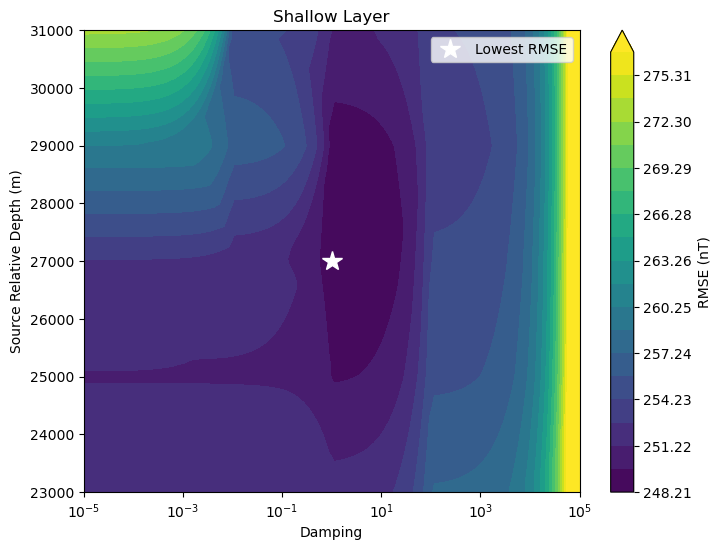

In [54]:
damping_values_shallow = np.array(damping_shallow)
depth_values_shallow = np.array(source_depth_shallow)
score_values_shallow = np.array(scores_shallow)

best_shallow = np.argmin(score_values_shallow)
best_damping_shallow = damping_values_shallow[best_shallow]
best_depth_shallow = depth_values_shallow[best_shallow]
best_rmse_shallow = score_values_shallow[best_shallow]
best_params_shallow = parameter_sets_shallow[best_shallow]
print("Best parameters:", best_params_shallow)
print(f"Best RMSE: {best_rmse_shallow:.3f} nT")

x_shallow = np.logspace(np.log10(damping_values_shallow.min()), np.log10(damping_values_shallow.max()), 100)
y_shallow = np.linspace(depth_values_shallow.min(), depth_values_shallow.max(), 100)
X_shallow, Y_shallow = np.meshgrid(x_shallow, y_shallow)

Z_shallow = griddata(
    (damping_values_shallow, depth_values_shallow),
    score_values_shallow,
    (X_shallow, Y_shallow),
    method='linear'
)
plt.figure(figsize=(8, 6))
levels_shallow = np.linspace(
    Z_shallow.min(),
    np.nanpercentile(score_values_shallow, 80),
    20,
)
c = plt.contourf(
    X_shallow,
    Y_shallow,
    Z_shallow,
    levels=levels_shallow,
    cmap="viridis",
    extend='max',
)
plt.plot(
    best_damping_shallow,
    best_depth_shallow,
    '*',
    color='white',
    markersize=15,
    label='Lowest RMSE'
)
plt.xscale('log')
plt.xlabel('Damping')
plt.ylabel('Source Relative Depth (m)')
plt.colorbar(c, label='RMSE (nT)')
plt.legend()
plt.title("Shallow Layer")
plt.show()

In [55]:
%%time
eqs_shallow = sph.EquivalentSourcesMagGeodGB(window_size=200e3, **parameter_sets_shallow[best])
eqs_shallow.fit(coordinates, inclination, declination, residuals_deep)
print(eqs_shallow.window_size_)

Output()

200000.0
CPU times: user 1min 6s, sys: 114 ms, total: 1min 6s
Wall time: 11 s


Plot the predidted and the residuals of the shallow layer, to check if the eqs is good.

In [56]:
predicted_shallow =  hm.total_field_anomaly(eqs_shallow.predict(coordinates), inclination, declination)
residuals_shallow = residuals_deep - predicted_shallow 

predicted_b_shallow = eqs_shallow.predict(coordinates)

residuals_be_shallow = residuals_be_deep - predicted_b_shallow[0]
residuals_bn_shallow = residuals_bn_deep - predicted_b_shallow[1]
residuals_bu_shallow = residuals_bu_deep - predicted_b_shallow[2]

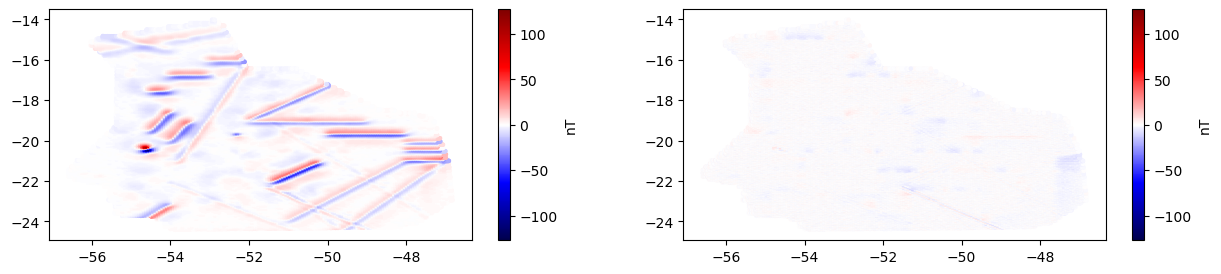

In [24]:
scale_deep = vd.maxabs(predicted_shallow)
plt.figure(figsize=(15,3))


plt.subplot(1,2,1)
plt.scatter(coordinates[0], coordinates[1],c = predicted_shallow, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

plt.subplot(1,2,2)
plt.scatter(coordinates[0], coordinates[1],c = residuals_shallow, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

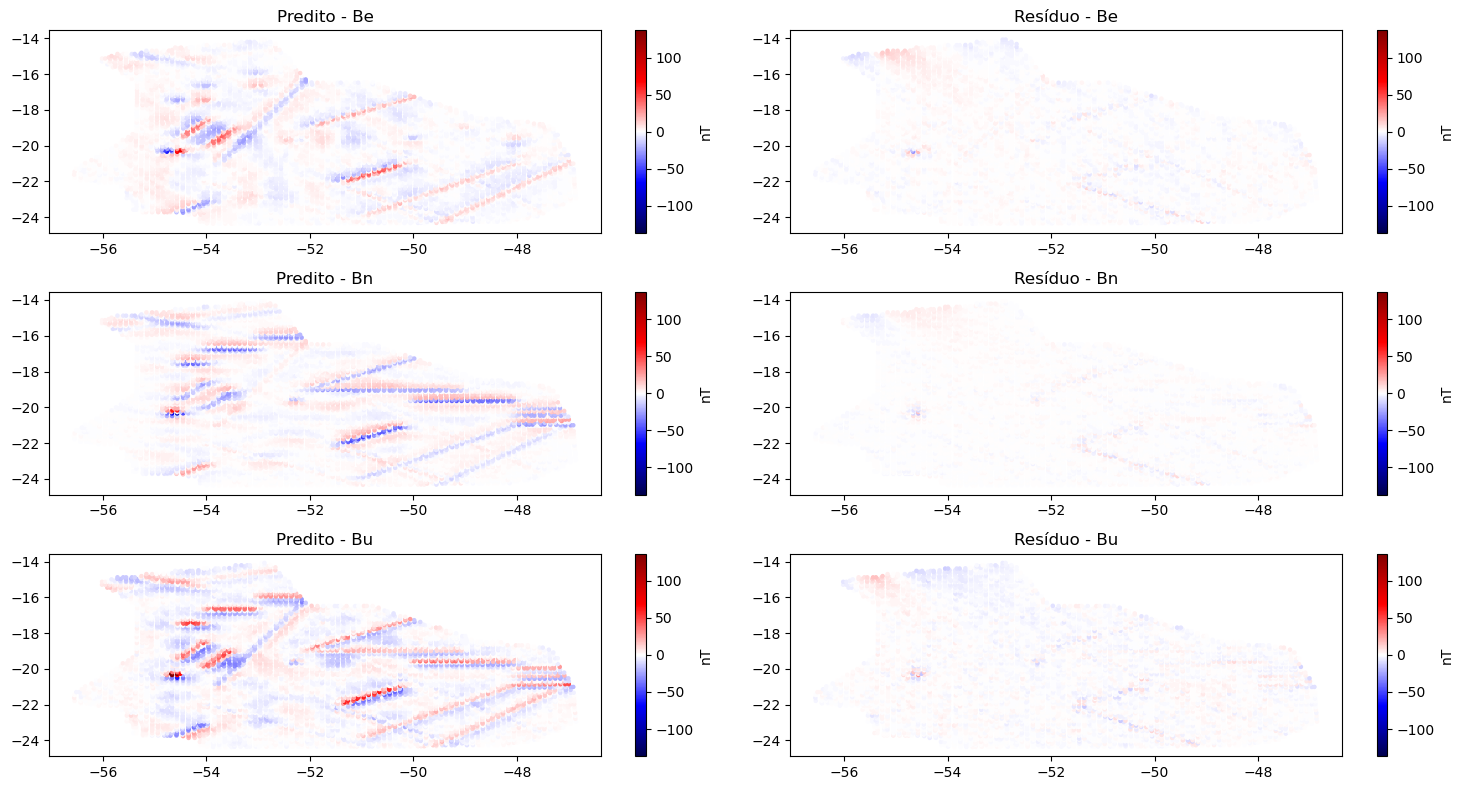

In [57]:
scale_b_shallow = vd.maxabs(predicted_b_shallow)
plt.figure(figsize=(15, 8))

# Componente E
plt.subplot(3, 2, 1)
plt.scatter(coordinates[0], coordinates[1], c=predicted_b_shallow[0], s=5,
            cmap="seismic", vmin=-scale_b_shallow, vmax=scale_b_shallow)
plt.colorbar(label='nT')
plt.title("Predito - Be")

plt.subplot(3, 2, 2)
plt.scatter(coordinates[0], coordinates[1], c=residuals_be_shallow, s=5,
            cmap="seismic", vmin=-scale_b_shallow, vmax=scale_b_shallow)
plt.colorbar(label='nT')
plt.title("Resíduo - Be")

# Componente N
plt.subplot(3, 2, 3)
plt.scatter(coordinates[0], coordinates[1], c=predicted_b_shallow[1], s=5,
            cmap="seismic", vmin=-scale_b_shallow, vmax=scale_b_shallow)
plt.colorbar(label='nT')
plt.title("Predito - Bn")

plt.subplot(3, 2, 4)
plt.scatter(coordinates[0], coordinates[1], c=residuals_bn_shallow, s=5,
            cmap="seismic", vmin=-scale_b_shallow, vmax=scale_b_shallow)
plt.colorbar(label='nT')
plt.title("Resíduo - Bn")

# Componente U
plt.subplot(3, 2, 5)
plt.scatter(coordinates[0], coordinates[1], c=predicted_b_shallow[2], s=5,
            cmap="seismic", vmin=-scale_b_shallow, vmax=scale_b_shallow)
plt.colorbar(label='nT')
plt.title("Predito - Bu")

plt.subplot(3, 2, 6)
plt.scatter(coordinates[0], coordinates[1], c=residuals_bu_shallow, s=5,
            cmap="seismic", vmin=-scale_b_shallow, vmax=scale_b_shallow)
plt.colorbar(label='nT')
plt.title("Resíduo - Bu")

plt.tight_layout()
plt.show()

Predict both on a regular grid and sum.

In [58]:
total_field_anomaly_predicted = vd.make_xarray_grid(
    grid_coord,
    hm.total_field_anomaly(eqs_deep.predict(grid_coord), inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid


total_field_anomaly_predicted += vd.make_xarray_grid(
    grid_coord,
    hm.total_field_anomaly(eqs_shallow.predict(grid_coord), inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

grided_dd_anomaly = vd.make_xarray_grid(
    grid_coord,
    grided_dd_anomaly,
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

In [59]:

b_predicted = vd.make_xarray_grid(
    grid_coord,
    eqs_deep.predict(grid_coord),
    data_names=("be","bn","bu"),
    dims=("latitude", "longitude"),
    extra_coords_names="height",
)

b_predicted+= vd.make_xarray_grid(
    grid_coord,
    eqs_shallow.predict(grid_coord),
    data_names=("be","bn","bu"),
    dims=("latitude", "longitude"),
    extra_coords_names="height",
)

grided_magnetic_field = vd.make_xarray_grid(
    grid_coord,
    magnetic_field_grid,
    data_names=("be","bn","bu"),
    dims=("latitude", "longitude"),
    extra_coords_names="height",
)

Plot the total field anomaly predicted, the true total field anomaly and the difference.

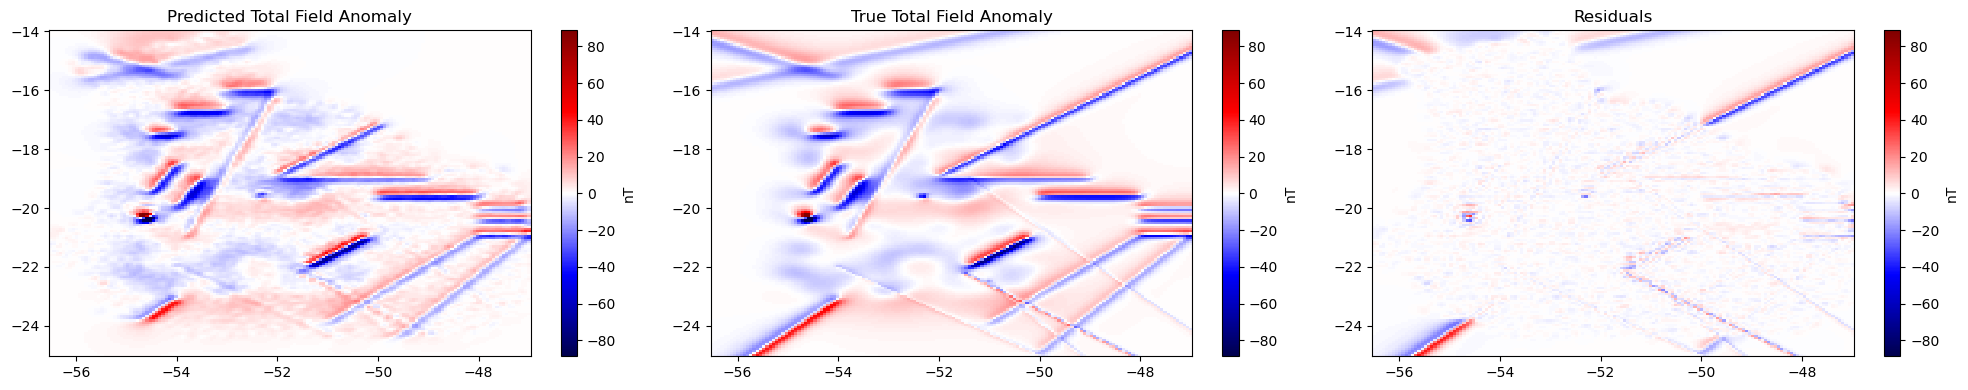

In [60]:
diff_grid_tfa = grided_dd_anomaly -  total_field_anomaly_predicted

plt.figure(figsize=(20,4))

plt.subplot(1,3,1)
plt.title("Predicted Total Field Anomaly")
plt.pcolormesh(
    *grid_coord[:2], total_field_anomaly_predicted, cmap="seismic", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')


plt.subplot(1,3,2)
plt.title("True Total Field Anomaly")
plt.pcolormesh(
    *grid_coord[:2], grided_dd_anomaly, cmap="seismic", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')


plt.subplot(1,3,3)
plt.title('Residuals')
plt.pcolormesh(
    *grid_coord[:2], diff_grid_tfa, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.tight_layout()

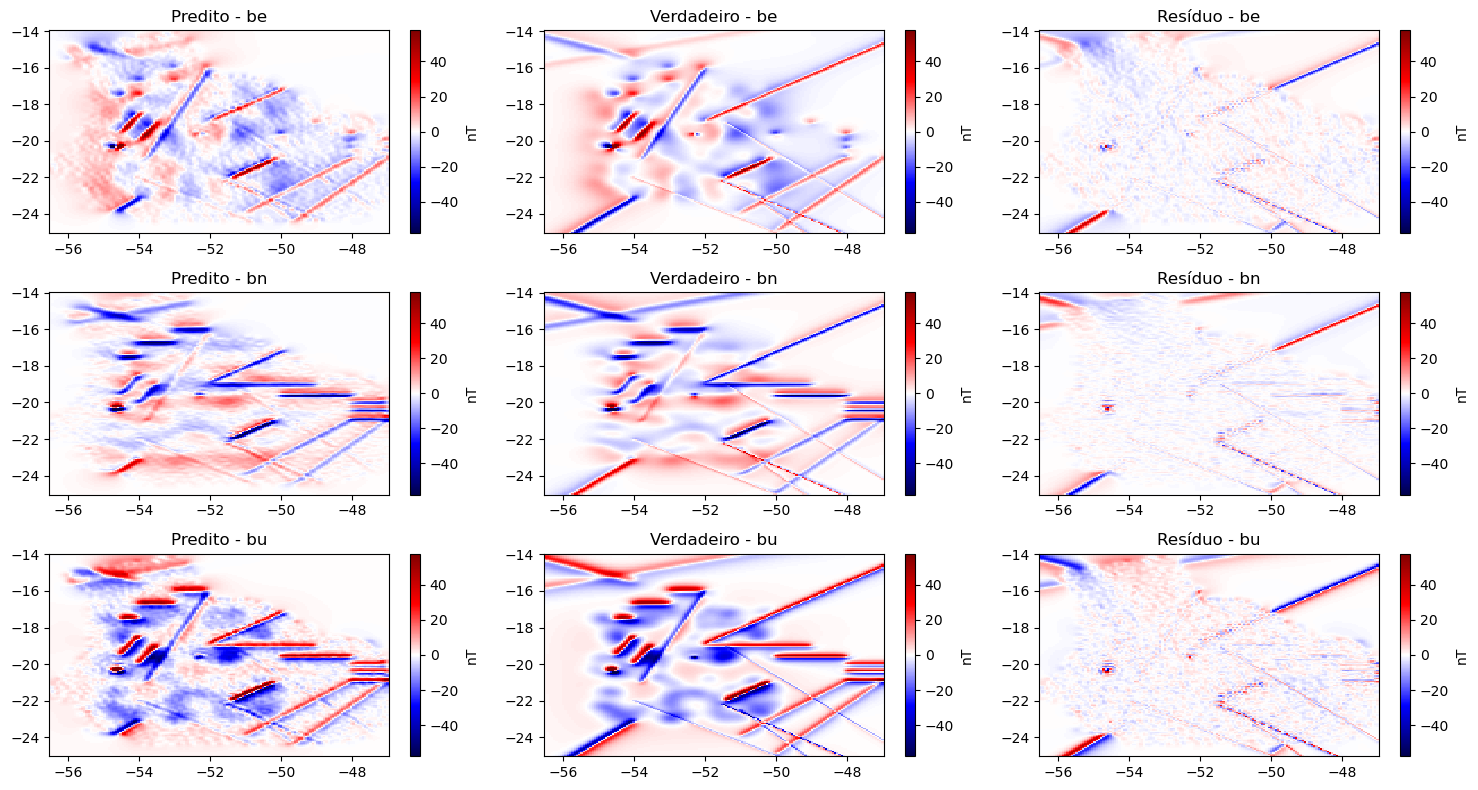

In [61]:

b_diff = b_predicted - grided_magnetic_field

scale_b_diff = vd.maxabs(b_diff.to_array())

plt.figure(figsize=(15, 8))

plt.subplot(3, 3, 1)
plt.title("Predito - be")
plt.pcolormesh(*grid_coord[:2], b_predicted["be"],
               cmap="seismic", vmin=-scale_b_diff, vmax=scale_b_diff)
plt.colorbar(label='nT')

plt.subplot(3, 3, 2)
plt.title("Verdadeiro - be")
plt.pcolormesh(*grid_coord[:2], grided_magnetic_field["be"],
               cmap="seismic", vmin=-scale_b_diff, vmax=scale_b_diff)
plt.colorbar(label='nT')

plt.subplot(3, 3, 3)
plt.title("Resíduo - be")
plt.pcolormesh(*grid_coord[:2], b_diff["be"],
               cmap="seismic", vmin=-scale_b_diff, vmax=scale_b_diff)
plt.colorbar(label='nT')

# Componente bn
plt.subplot(3, 3, 4)
plt.title("Predito - bn")
plt.pcolormesh(*grid_coord[:2], b_predicted["bn"],
               cmap="seismic", vmin=-scale_b_diff, vmax=scale_b_diff)
plt.colorbar(label='nT')

plt.subplot(3, 3, 5)
plt.title("Verdadeiro - bn")
plt.pcolormesh(*grid_coord[:2], grided_magnetic_field["bn"],
               cmap="seismic", vmin=-scale_b_diff, vmax=scale_b_diff)
plt.colorbar(label='nT')

plt.subplot(3, 3, 6)
plt.title("Resíduo - bn")
plt.pcolormesh(*grid_coord[:2], b_diff["bn"],
               cmap="seismic", vmin=-scale_b_diff, vmax=scale_b_diff)
plt.colorbar(label='nT')

# Componente bu
plt.subplot(3, 3, 7)
plt.title("Predito - bu")
plt.pcolormesh(*grid_coord[:2], b_predicted["bu"],
               cmap="seismic", vmin=-scale_b_diff, vmax=scale_b_diff)
plt.colorbar(label='nT')

plt.subplot(3, 3, 8)
plt.title("Verdadeiro - bu")
plt.pcolormesh(*grid_coord[:2], grided_magnetic_field["bu"],
               cmap="seismic", vmin=-scale_b_diff, vmax=scale_b_diff)
plt.colorbar(label='nT')

plt.subplot(3, 3, 9)
plt.title("Resíduo - bu")
plt.pcolormesh(*grid_coord[:2], b_diff["bu"],
               cmap="seismic", vmin=-scale_b_diff, vmax=scale_b_diff)
plt.colorbar(label='nT')

plt.tight_layout()
plt.show()


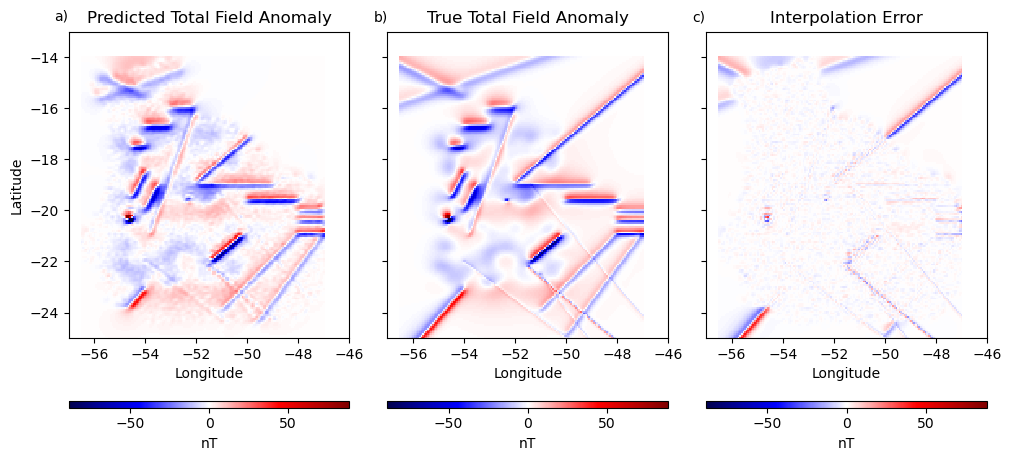

In [62]:
region = [-57, -46, -25, -13]
fig, axes = plt.subplots(1, 3, figsize=(10, 4.5), sharey=True, layout="constrained")  


im0 = axes[0].pcolormesh(*grid_coord[:2], total_field_anomaly_predicted, cmap="seismic", vmin=-scale, vmax=scale)
axes[0].set_title("Predicted Total Field Anomaly")
axes[0].set_ylabel("Latitude")
axes[0].set_aspect("equal")

im1 = axes[1].pcolormesh(*grid_coord[:2], grided_dd_anomaly, cmap="seismic", vmin=-scale, vmax=scale)
axes[1].set_title("True Total Field Anomaly")
axes[1].set_aspect("equal")


diff_grid_tfa = grided_dd_anomaly - total_field_anomaly_predicted
im2 = axes[2].pcolormesh(*grid_coord[:2], diff_grid_tfa, cmap="seismic", vmin=-scale, vmax=scale)
axes[2].set_title(f"Interpolation Error")
axes[2].set_aspect("equal")


cb0 = fig.colorbar(im0, ax=axes[0], orientation="horizontal", aspect=40)
cb0.set_label("nT")
cb1 = fig.colorbar(im1, ax=axes[1], orientation="horizontal", aspect=40)
cb1.set_label("nT")
cb2 = fig.colorbar(im2, ax=axes[2], orientation="horizontal", aspect=40)
cb2.set_label("nT")

for ax in axes.ravel():
    ax.set_xlim(*region[:2])
    ax.set_ylim(*region[2:])
    ax.set_xlabel("Longitude")

for ax, label in zip(axes, "abc"):
    ax.text(-0.05, 1.035, f"{label})", transform=ax.transAxes)

# plt.savefig("total_field_anomaly_inversion-gb.png", dpi=200, format='png')
plt.show()


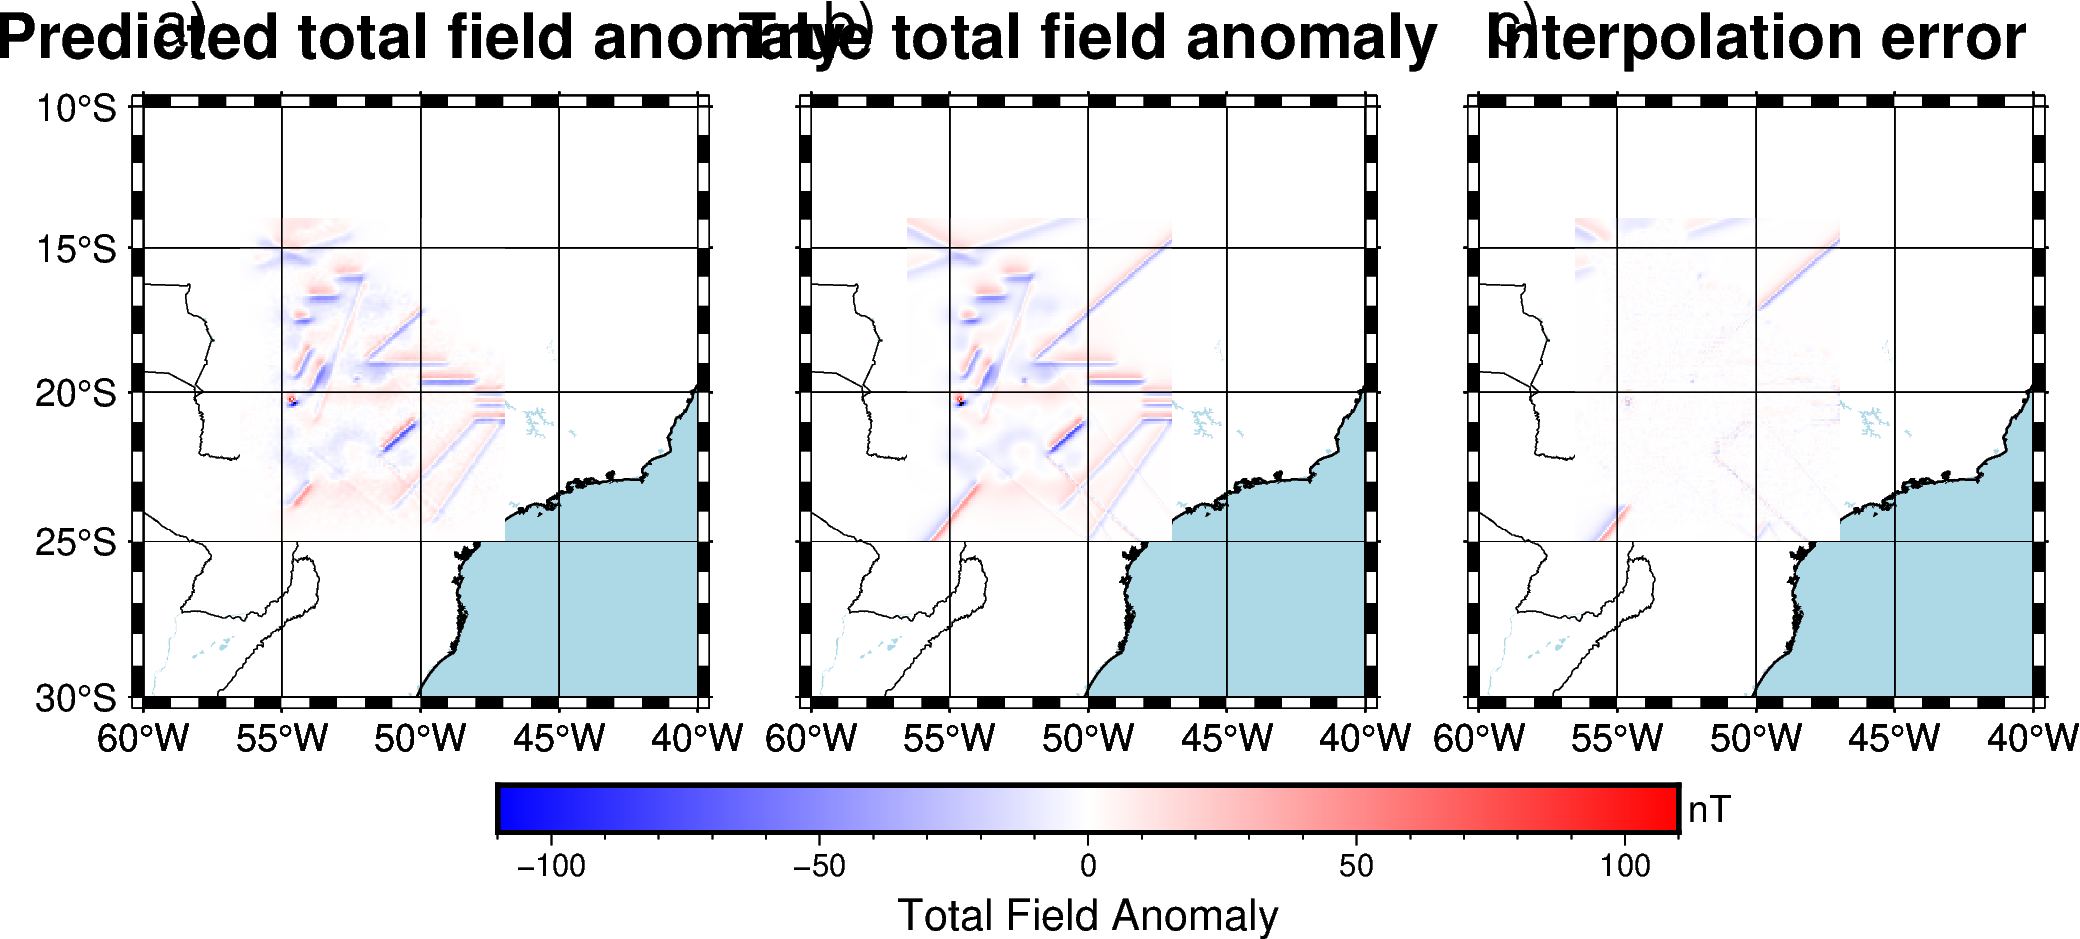

In [63]:
region_coast = [-60, -40, -30, -10]
scale = 110

fig = pygmt.Figure()

with fig.subplot(nrows=1, ncols=3, figsize=("16c", "7c"), margins="0.25c", autolabel=True):

    with fig.set_panel(panel=0):
        pygmt.makecpt(cmap="polar+h", series=[-scale, scale])
        fig.coast(
            region=region_coast,
            projection="M?",
            frame="afg",
            land="white",
            water="lightblue",
            shorelines="1/0.5p,black",
            borders=[1], 
        )
        fig.grdimage(
            grid=total_field_anomaly_predicted,
            region=region_coast,
            projection="M?",
            cmap=True,
            frame=['wSne',"xafg", "yafg"]
        )
        fig.text(
            text="Predicted total field anomaly",
            position="TC",
            font="15p,Helvetica-Bold,black",
            offset="0/0.8c",
            no_clip=True,
        )

    with fig.set_panel(panel=1):
        pygmt.makecpt(cmap="polar+h", series=[-scale, scale])
        
        fig.coast(
            region=region_coast,
            projection="M?",
            frame=["wSne","xafg", "yafg"],
            land="white",
            water="lightblue",
            shorelines="1/0.5p,black",
            borders=[1],
        )
        fig.grdimage(
            grid=grided_dd_anomaly,
            region=region_coast,
            projection="M?",
            cmap=True,
            frame=["wSne","xafg", "yafg"]
        )
        fig.text(
            text="True total field anomaly",
            position="TC",
            font="15p,Helvetica-Bold,black",
            offset="0/0.8c",
            no_clip=True,
        )
        fig.colorbar(
            position="JBC+w10c",
            frame=["x+lTotal Field Anomaly", "y+lnT"]
        )

    with fig.set_panel(panel=2):
        pygmt.makecpt(cmap="polar+h", series=[-scale, scale])
        fig.coast(
            region=region_coast,
            projection="M?",
            frame=["wSne","xafg", "yafg"],
            land="white",
            water="lightblue",
            shorelines="1/0.5p,black",
            borders=[1],
        )
        fig.grdimage(
            grid=(grided_dd_anomaly - total_field_anomaly_predicted),
            region=region_coast,
            projection="M?",
            cmap=True,
            frame=["wSne","xafg", "yafg"]
        )
        fig.text(
            text="Interpolation error",
            position="TC",
            font="15p,Helvetica-Bold,black",
            offset="0/0.8c",
            no_clip=True,
        )

fig.show(width=1500)
# fig.savefig(fname= "figures/total_field_anomaly_inversion_parana_basin-gb.png", transparent=True)
